# Linear Regression Exercise

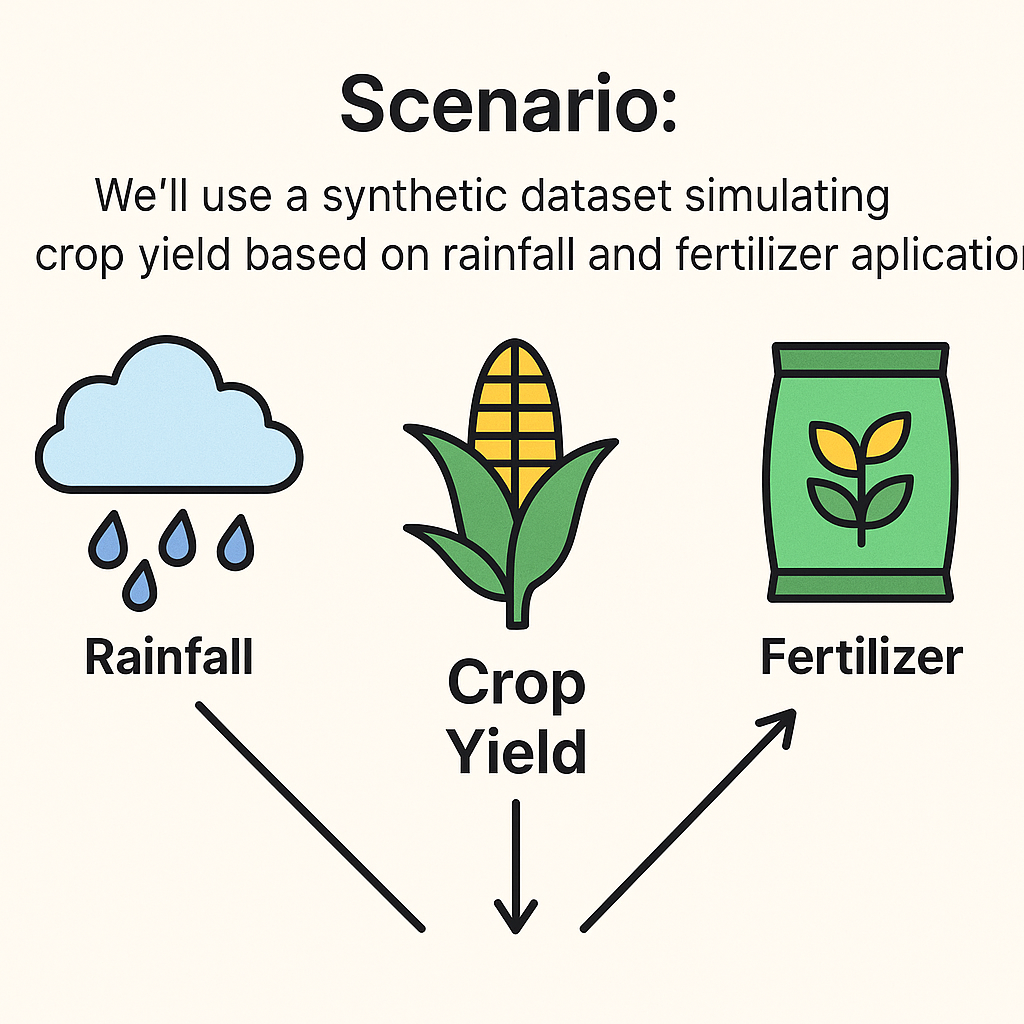

## 1. Setup, Imports and Data Loading

Import libraries, load the dataset, import our custom implementations, and add necessary sklearn modules.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as SkLinearRegression  # Alias to avoid name clash

# --- Import your custom implementations ---

from mlab.regression._linear import LinearRegressor, SGDRegression


def evaluate_model(y_true, y_pred):
    """Calculates MSE, RMSE, and R-squared.
        Args:
            y_true (np.ndarray): True target values (m x 1 or flat).
            y_pred (np.ndarray): Predicted values (m x 1 or flat).
        Returns:
            dict: Dictionary containing 'MSE', 'RMSE', 'R2'.
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    m = len(y_true)
    if m == 0: return {'MSE': np.nan, 'RMSE': np.nan, 'R2': np.nan}
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    rss = np.sum((y_true - y_pred) ** 2)
    if tss == 0:
        r2 = 1.0 if rss < 1e-9 else 0.0
    else:
        r2 = 1 - (rss / tss)
    return {'MSE': mse, 'RMSE': rmse, 'R2': r2}


# Set plot style
sns.set_theme(style="whitegrid")

# Load the dataset 
DATA_FILENAME = "datasets/crop_yield_saturation_data.csv"
try:
    df = pd.read_csv(DATA_FILENAME)
except FileNotFoundError:
    print(f"Error: Dataset file '{DATA_FILENAME}' not found.")
    df = pd.DataFrame()

if not df.empty:
    print("Dataset loaded successfully.")
    print(f"Shape: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())

Dataset loaded successfully.
Shape: (10000, 3)

First 5 rows:
   Rainfall_mm  Fertilizer_kg_ha  Yield_tons_ha
0   749.671415         96.376552       6.816294
1   686.173570         30.905758       4.777932
2   764.768854         21.542264       6.131191
3   852.302986         28.282793       5.047024
4   676.584663        174.860808       7.731765


## 2. Data Analysis (Optional)

We visualize the **entire dataset** to understand its overall structure.

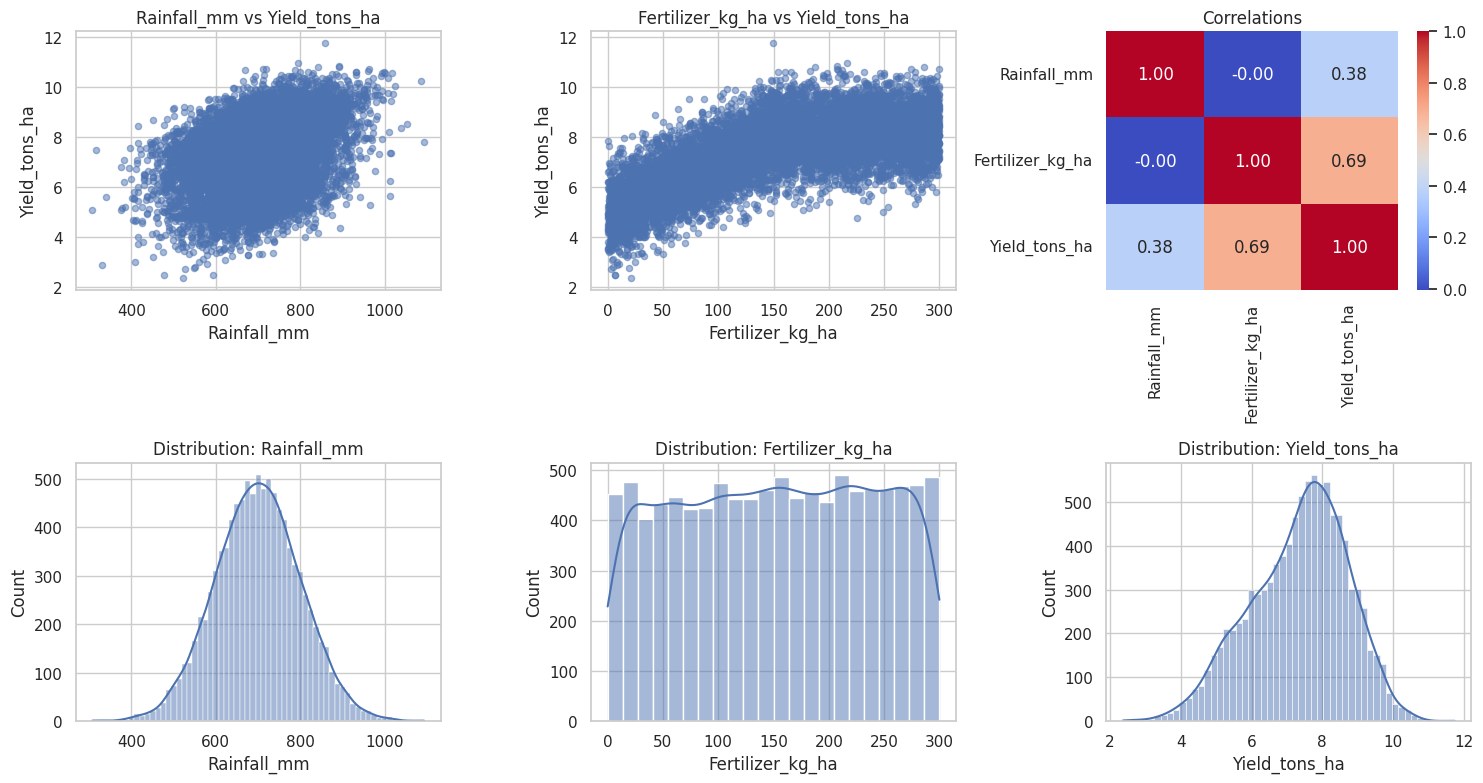

In [15]:
# Generated by Claude
if not df.empty:
    target_col = "Yield_tons_ha"
    feature_cols = [c for c in df.columns if c != target_col]

    n_cols = len(feature_cols) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8))

    # row 1: feature vs target
    for ax, col in zip(axes[0, :-1], feature_cols):
        ax.scatter(df[col], df[target_col], alpha=0.5, s=20)
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.set_title(f"{col} vs {target_col}")

    # correlation heatmap (spans last column, row 1)
    sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
                cmap="coolwarm", ax=axes[0, -1])
    axes[0, -1].set_title("Correlations")

    # row 2: distributions
    for ax, col in zip(axes[1], df.columns):
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f"Distribution: {col}")

    # hide unused last axis in row 2 if any
    if len(df.columns) < n_cols:
        axes[1, -1].set_visible(False)

    plt.tight_layout()
    plt.show()

## 3. Train-Test Split

Now we split the data into training and testing sets. The model will be trained on the training set and evaluated on the unseen test set to assess its generalization performance.

In [16]:
X_train, X_test, y_train, y_test = None, None, None, None  # Initialize
X_naive_train, X_naive_test = None, None  # For the naive model features

X = df[["Rainfall_mm", "Fertilizer_kg_ha"]].to_numpy(dtype=np.float64)
y = df["Yield_tons_ha"].to_numpy(dtype=np.float64)

if X is not None and y is not None:
    # We use random_state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data split into training and testing sets.")
    print(f"Training Features Shape: {X_train.shape}")
    print(f"Testing Features Shape: {X_test.shape}")
    print(f"Training Target Shape: {y_train.shape}")
    print(f"Testing Target Shape: {y_test.shape}")
else:
    print("Feature matrix 'X' or target 'y' not available. Skipping train-test split.")

Data split into training and testing sets.
Training Features Shape: (8000, 2)
Testing Features Shape: (2000, 2)
Training Target Shape: (8000,)
Testing Target Shape: (2000,)


## 4. LinearRegression (Using `mlab.LinearRegressor`)

Let's fit a standard linear model using our custom `LinearRegressor` class (which uses the Normal Equation) and evaluate on both train and test sets.

In [17]:
linearRegressor = LinearRegressor().fit(X_train, y_train)
y_hat = linearRegressor.predict(X_test)
print(y_hat[0:10])
print(y_test[0:10])

[8.54009818 7.29310404 5.66743667 6.47799555 6.87935175 5.64284542
 8.18017539 5.90142996 7.85084736 8.63108277]
[8.5492143  7.7709919  5.56289119 6.85996888 6.76803683 5.99997492
 7.04903755 6.2218255  9.11247244 9.88876654]


## 5. LinearRegression (Using `mlab.SGDRegressor`)

Now let's fit using our Gradient Descent implementation. Remember to scale features for GD!


In [18]:
#TODO

## 6. Using Scikit-learn 

Let's compare our results with Scikit-learn, using its built-in tools for polynomial feature generation.

In [19]:
skLinearRegressor = SkLinearRegression()
skLinearRegressor.fit(X_train, y_train)
y_hat = skLinearRegressor.predict(X_test)

print(y_hat[0:10])
print(y_test[0:10])

[8.54009818 7.29310404 5.66743667 6.47799555 6.87935175 5.64284542
 8.18017539 5.90142996 7.85084736 8.63108277]
[8.5492143  7.7709919  5.56289119 6.85996888 6.76803683 5.99997492
 7.04903755 6.2218255  9.11247244 9.88876654]


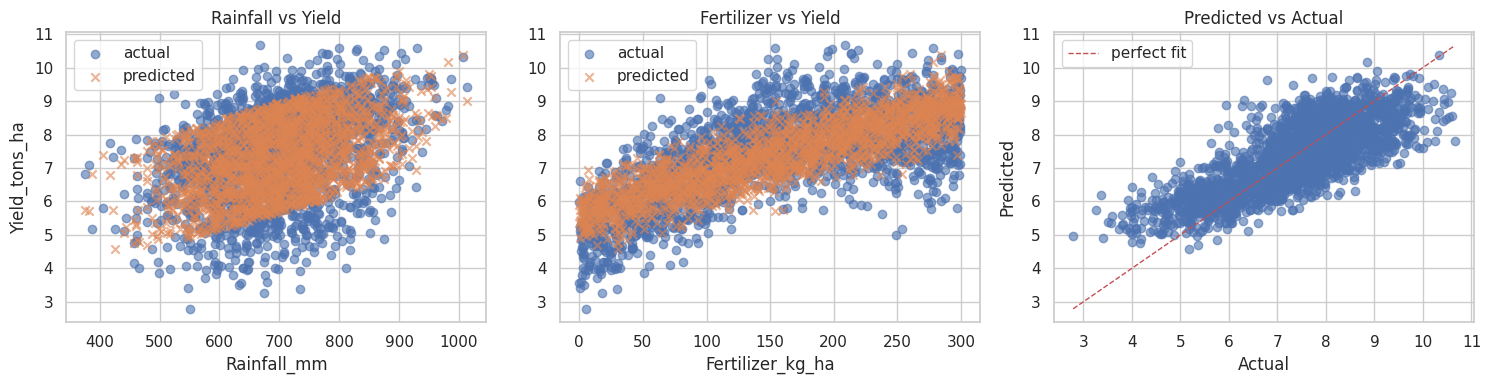

In [20]:
# Generated by Claude

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 1. Rainfall vs yield with fitted line ──────────────────────────
ax = axes[0]
ax.scatter(X_test[:, 0], y_test, alpha=0.6, label="actual")
ax.scatter(X_test[:, 0], linearRegressor.predict(X_test), alpha=0.6, marker="x", label="predicted")
ax.set_xlabel("Rainfall_mm")
ax.set_ylabel("Yield_tons_ha")
ax.set_title("Rainfall vs Yield")
ax.legend()

# ── 2. Fertilizer vs yield with fitted line ────────────────────────
ax = axes[1]
ax.scatter(X_test[:, 1], y_test, alpha=0.6, label="actual")
ax.scatter(X_test[:, 1], linearRegressor.predict(X_test), alpha=0.6, marker="x", label="predicted")
ax.set_xlabel("Fertilizer_kg_ha")
ax.set_title("Fertilizer vs Yield")
ax.legend()

# ── 3. Predicted vs actual ─────────────────────────────────────────
ax = axes[2]
y_pred = linearRegressor.predict(X_test)
ax.scatter(y_test, y_pred, alpha=0.6)
# perfect prediction line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="perfect fit")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
ax.legend()

plt.tight_layout()
plt.savefig("model_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # transform only, not fit_transform

skLinearRegressor = SkLinearRegression()
skLinearRegressor.fit(X_train_poly, y_train)
y_hat_poly = skLinearRegressor.predict(X_test_poly)

print(y_hat_poly[0:10])
print(y_test[0:10])

[8.96981537 7.60231015 5.07366125 6.55992551 6.83526391 5.39329644
 8.34096879 5.27439096 8.24804487 8.21696481]
[8.5492143  7.7709919  5.56289119 6.85996888 6.76803683 5.99997492
 7.04903755 6.2218255  9.11247244 9.88876654]


In [23]:
print("Linear:     ", evaluate_model(y_test, y_hat))
print("Polynomial: ", evaluate_model(y_test, y_hat_poly))

Linear:      {'MSE': np.float64(0.75291299988586), 'RMSE': np.float64(0.8677055951680039), 'R2': np.float64(0.5961791347334081)}
Polynomial:  {'MSE': np.float64(0.5894410755783278), 'RMSE': np.float64(0.7677506597706887), 'R2': np.float64(0.6838564280337893)}


In [26]:
# Generated by Claude
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=["Linear  R²=0.596", "Polynomial  R²=0.684"]
)

# ── shared grid ────────────────────────────────────────────────────
r_range = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 40)
f_range = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 40)
R, F = np.meshgrid(r_range, f_range)
grid = np.column_stack([R.ravel(), F.ravel()])

Z_linear = linearRegressor.predict(grid).reshape(R.shape)
Z_poly = skLinearRegressor.predict(poly.transform(grid)).reshape(R.shape)

# ── linear surface ─────────────────────────────────────────────────
fig.add_trace(go.Surface(x=R, y=F, z=Z_linear, opacity=0.5,
                         colorscale="Blues", showscale=False, name="Linear"), row=1, col=1)
fig.add_trace(go.Scatter3d(
    x=X_test[:, 0], y=X_test[:, 1], z=y_test,
    mode="markers", marker=dict(size=2, color="red", opacity=0.5),
    name="Actual"), row=1, col=1)

# ── polynomial surface ─────────────────────────────────────────────
fig.add_trace(go.Surface(x=R, y=F, z=Z_poly, opacity=0.5,
                         colorscale="Oranges", showscale=False, name="Polynomial"), row=1, col=2)
fig.add_trace(go.Scatter3d(
    x=X_test[:, 0], y=X_test[:, 1], z=y_test,
    mode="markers", marker=dict(size=2, color="red", opacity=0.5),
    name="Actual"), row=1, col=2)

fig.update_layout(
    height=600,
    scene=dict(xaxis_title="Rainfall", yaxis_title="Fertilizer", zaxis_title="Yield"),
    scene2=dict(xaxis_title="Rainfall", yaxis_title="Fertilizer", zaxis_title="Yield"),
)

fig.show()